## Series de tiempo - Taller 1

### Librerías usadas en el taller 1

In [38]:
import numpy as np                                    ### Cálculos numéricos y métricas descriptivas
import pandas as pd                                   ### Manejo, manipulación y transformación de datos
import matplotlib.pyplot as plt                       ### Gráficos básicos en Python  
import seaborn as sns                                 ### Gráficos estadísticos en Python
import statsmodels.api as sm                          ### Estimación por MCO

from pathlib import Path                              ### Manejo de rutas y directorios

#### Definimos la carpeta de destino

In [17]:
data_folder = Path.cwd().parent / 'data'

data_folder

WindowsPath('c:/Users/fevid/Documents/GitHub/time-series-Uniandes/data')

#### Cargamos la base de datos de nlsy79

In [18]:
df_1 = pd.read_excel(data_folder/'nlsy79_regresion.xlsx')

df_1.head(10)

,salario_hora,no_ambos_padres_bio,educacion,edad,afqt_score,mujer,hispano,negro
0,6.78,0,12,51,12.0,1,0,0
1,43.41,0,16,49,99.0,0,0,0
2,14.35,1,12,45,33.0,0,0,0
3,20.19,0,14,51,43.0,1,0,0
4,21.15,1,14,46,55.0,0,0,0
5,40.59,0,19,46,88.0,1,0,0
6,NaN,0,16,45,83.0,0,0,0
7,28.63,0,13,51,63.0,1,0,0
8,27.02,1,13,53,84.0,0,0,0
9,NaN,0,12,51,NaN,1,0,0


#### Propuesta de modelo de predicción:

$Ln(W_{i}) = \beta_{0} + \beta_{1}S_{i} + \beta_{2}AFQT_{i} + \beta_{3}Mujer_{i} + \beta_{4}Hispano_{i} + \beta_{5}Negro + \epsilon_{i}$

$W_{i}:$ es el nivel salarial por hora de la persona $i$ en dólares americanos

$S_{i}:$ el número de años de escolaridad reportado por la persona $i$

$AFQT_{i}:$ puntaje percentil en el Armed Forces Qualification Test de la persona $i$ (proxy de habilidad cognitiva).

$Mujer_{i}:$ variable dummy que toma el valor de 1 si la persona $i$ es mujer y 0 si es hombre.

$Hispano_{i}:$ variable dummy que toma el valor de 1 si la persona $i$ pertenece a este grupo étnico/racial y 0 en caso contrario.

$Negro_{i}:$ variable dummy que toma el valor de 1 si la persona $i$ pertenece a este grupo étnico/racial y 0 en caso contrario.

$\epsilon_{i}:$ error de medición


## Preliminares:

<b>1) ¿Cuál es el pronóstico óptimo para el salario de la persona $i$?<b>

<b>b) Discuta los supuestos necesarios para que el pronóstico propuesto sea, de hecho, óptimo<b>

a) 



<b>2) Usando las observaciones de la muestra (las que reportan salarios), haga diagramas de dispersión del logaritmo natural de los salarios con respecto a la educación y al puntaje AFQT. Discuta qué espera de los parámetros del modelo en términos de signo y significancia<b>

In [19]:
#### Filtramos los NaN para las variables de salarios por hora, AFQT y Educación
df_wage = df_1.dropna(subset = ['salario_hora', 
                                'afqt_score', 
                                'educacion']).copy()

#### Creamos la variable del logaritmo natural de los salarios
df_wage['ln_salario_hora'] = np.log(df_wage['salario_hora'])

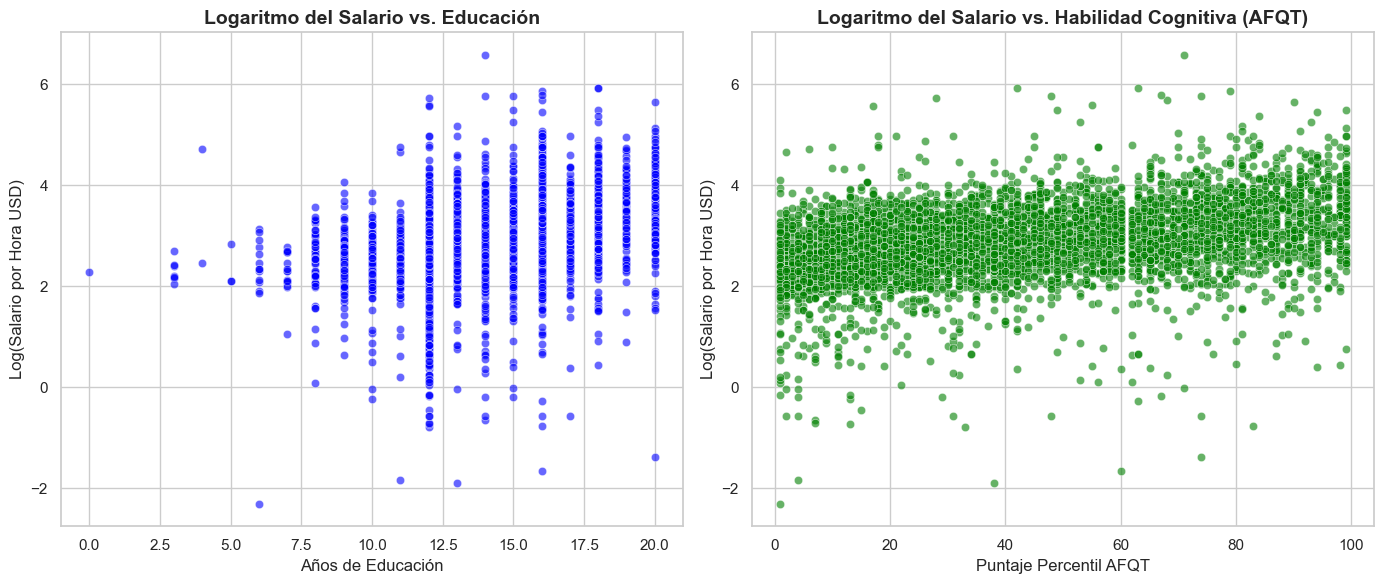

In [20]:
fig, axes = plt.subplots(nrows = 1, 
                         ncols = 2, 
                         figsize = (14, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data = df_wage, 
    x = 'educacion', 
    y = 'ln_salario_hora', 
    alpha =0.6, 
    ax = axes[0],
    color = 'blue'
)
axes[0].set_title('Logaritmo del Salario vs. Educación', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Años de Educación', fontsize=12)
axes[0].set_ylabel('Log(Salario por Hora USD)', fontsize=12)

sns.scatterplot(
    data = df_wage, 
    x = 'afqt_score', 
    y = 'ln_salario_hora', 
    alpha = 0.6, 
    ax = axes[1],
    color = 'green'
)
axes[1].set_title('Logaritmo del Salario vs. Habilidad Cognitiva (AFQT)', 
                  fontsize = 14, 
                  fontweight = 'bold')
axes[1].set_xlabel('Puntaje Percentil AFQT', 
                   fontsize = 12)
axes[1].set_ylabel('Log(Salario por Hora USD)', 
                   fontsize = 12)

plt.tight_layout()
plt.show()

La gráfica de la Educación vs el logaritmo del salario muestra una relación lineal positiva, sin embargo, existe una elevada dispersión de los datos para cada año de educación, por lo tanto esperamos que el signo del estimador de los años de educación sea positivo y significativo bajo una confianza del 95%. Por otra parte, la gráfica del AFQT también muestra una relación positiva con una menor dispersión, aunque con más cantidad de datos atípicos, por lo que consideramos que el beta tendrá un signo positivo y será significativo.

<b>3) Estime el modelo [1] por MCO. Reporte el $R^{2}$ y $R^{2}_{ajustado}$, e interprételos desde una perspectiva de pronóstico<b>

In [21]:
df_wage.head()

,salario_hora,no_ambos_padres_bio,educacion,edad,afqt_score,mujer,hispano,negro,ln_salario_hora
0,6.78,0,12,51,12.0,1,0,0,1.913977
1,43.41,0,16,49,99.0,0,0,0,3.770690
2,14.35,1,12,45,33.0,0,0,0,2.663750
3,20.19,0,14,51,43.0,1,0,0,3.005187
4,21.15,1,14,46,55.0,0,0,0,3.051640


In [ ]:
#### Matriz de variables independientes (X)
X = df_wage.drop(['salario_hora', 'no_ambos_padres_bio', 'edad', 'ln_salario_hora'], axis = 1)

#### Añadimos el intercepto a la matriz X
X = sm.add_constant(X)

#### Creamos la variable dependiente Y
Y = df_wage['ln_salario_hora']

#### Estimamos el modelo_1 por MCO
modelo_1 = sm.OLS(Y, X).fit()
print(modelo_1.summary())

#### Reportar los R2
r_cuadrado = modelo_1.rsquared
r_cuadrado_ajustado = modelo_1.rsquared_adj

print()

                            OLS Regression Results                            
Dep. Variable:        ln_salario_hora   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     329.8
Date:               jue, 27 ago. 2026   Prob (F-statistic):          6.47e-312
Time:                        20:07:22   Log-Likelihood:                -5681.8
No. Observations:                5821   AIC:                         1.138e+04
Df Residuals:                    5815   BIC:                         1.142e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6988      0.050     33.998      0.0

El $R^{2}$ es igual a 22,1%, este no es un indicador fuerte para un modelo de pronóstico, ya que este aumenta su valor cuando se le añaden más variables independientes al modelo de regresión lineal múltiple.

El $R^{2}_{ajustado}$ es igual a 22%, este nos permite comparar entre distintos modelos candidatos al pronóstico debido a que esta métrica penaliza el número de variables independientes. 

<b>4) 4.	Sin hacer simulaciones, pronostiquen el salario para los individuos que no lo reportan. Tenga en cuenta que, dentro del grupo de personas que no reportan salario, algunas tampoco reportan el puntaje AFQT (test de habilidad cognitiva) — como el modelo [1] requiere AFQT como regresor, usted debe eliminar de este ejercicio de pronóstico a las personas que no reporten AFQT, ya que para ellas no es posible calcular la predicción. Presente sus resultados en forma de gráfico de dispersión con el número de años de escolaridad en el eje horizontal y salario en el eje vertical.<b>

In [34]:
df_no_wage = df_1[df_1['salario_hora'].isna()].copy()

df_no_wage

,salario_hora,no_ambos_padres_bio,educacion,edad,afqt_score,mujer,hispano,negro
6,NaN,0,16,45,83.0,0,0,0
9,NaN,0,12,51,NaN,1,0,0
15,NaN,0,13,46,93.0,1,0,0
17,NaN,0,12,51,14.0,1,0,0
20,NaN,0,12,48,NaN,0,1,0
...,...,...,...,...,...,...,...,...
7519,NaN,1,12,48,2.0,0,0,1
7520,NaN,1,16,49,15.0,0,0,1
7523,NaN,1,12,52,3.0,0,0,1
7532,NaN,1,13,46,30.0,1,1,0


In [35]:
print("Variables que el modelo espera:", modelo_1.model.exog_names)

Variables que el modelo espera: ['const', 'educacion', 'afqt_score', 'mujer', 'hispano', 'negro']


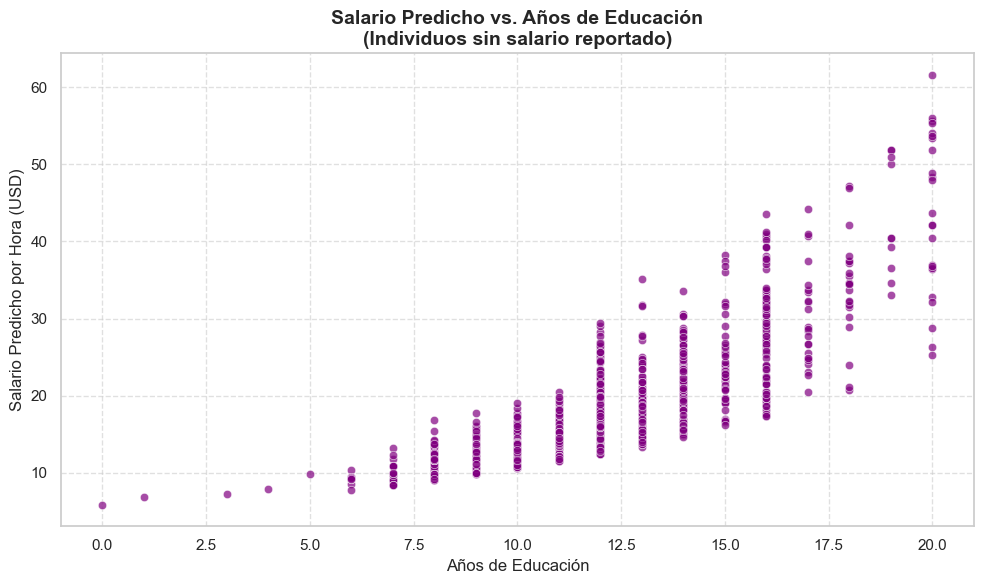

In [39]:
var_indep = ['educacion', 'afqt_score', 'mujer', 'hispano', 'negro']

df_predict = df_no_wage.dropna(subset = var_indep).copy()

X_pred = df_predict[var_indep]
X_pred = sm.add_constant(X_pred, has_constant = 'add')

df_predict['ln_salario_pred'] = modelo_1.predict(X_pred)

sigma2_hat = modelo_1.mse_resid

df_predict['forecast_wage'] = np.exp(df_predict['ln_salario_pred'] + (sigma2_hat / 2))

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_predict, 
    x = 'educacion', 
    y='forecast_wage', 
    alpha=0.7, 
    color='purple'
)
plt.title('Salario Predicho vs. Años de Educación\n(Individuos sin salario reportado)', fontsize=14, fontweight='bold')
plt.xlabel('Años de Educación', fontsize=12)
plt.ylabel('Salario Predicho por Hora (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

El resultado del pronóstico (salario por hora) vs los años de educación muestra una relación lineal positiva entre las dos variables. Esto implica que entre más años de educación tengan los individuos, en promedio, su salario va a aumentar.

<b> 5)	Usando las observaciones de la muestra (las que reportan salarios), haga diagramas de dispersión del logaritmo de los salarios con respecto a la educación y al puntaje AFQT. A diferencia del numeral 2, en este numeral usted debe hacer 4 gráfico. <b>

<b>a) Los dos primeros: salarios vs educación y salarios vs. AFQT diferenciando los puntos del gráfico entre personas con No_Ambos_Padres_Bio = 1 y No_Ambos_Padres_Bio = 0.
<b>

Text(0, 0.5, 'Log(Salario)')

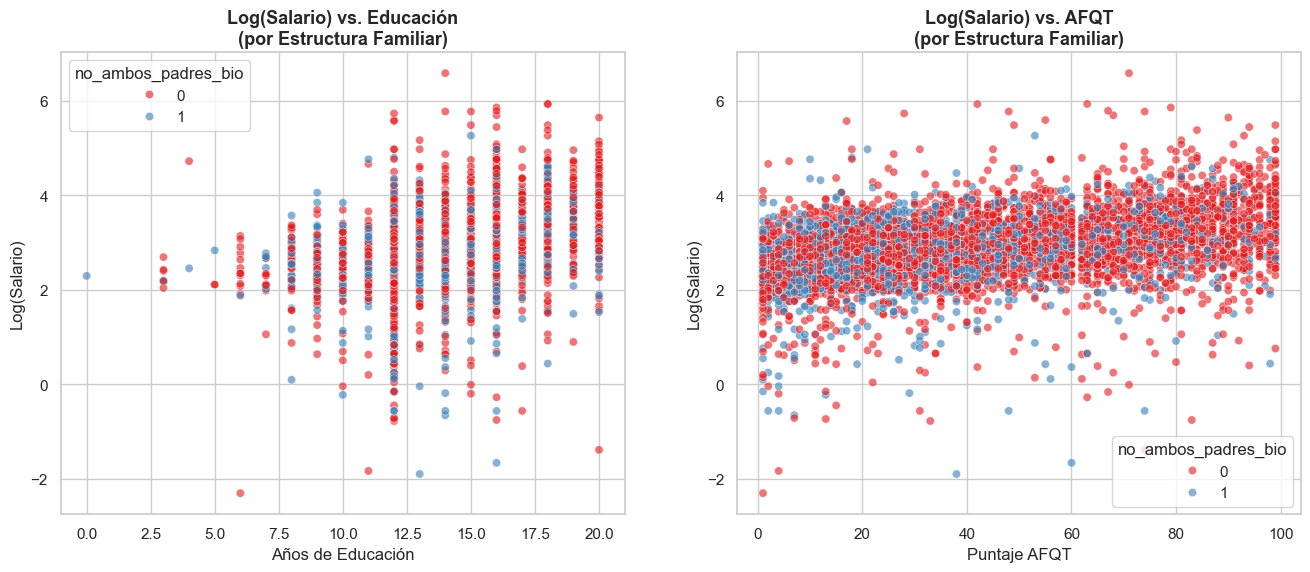

In [45]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data = df_wage, 
    x='educacion', 
    y='ln_salario_hora', 
    hue='no_ambos_padres_bio', 
    palette='Set1', 
    alpha=0.6, 
    ax = axes[0]
)
axes[0].set_title('Log(Salario) vs. Educación\n(por Estructura Familiar)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Años de Educación')
axes[0].set_ylabel('Log(Salario)')

# 2. Log(Salario) vs. AFQT por Estructura Familiar
sns.scatterplot(
    data = df_wage, 
    x='afqt_score', 
    y='ln_salario_hora', 
    hue='no_ambos_padres_bio', 
    palette='Set1', 
    alpha=0.6, 
    ax=axes[1]
)
axes[1].set_title('Log(Salario) vs. AFQT\n(por Estructura Familiar)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Puntaje AFQT')
axes[1].set_ylabel('Log(Salario)')

<b>b) Los dos siguientes: salarios vs educación y salarios vs. AFQT diferenciando los puntos del gráfico por grupo racial/étnico de la persona (variable Raza).
 <b>

In [46]:
df_wage['raza'] = 'Blanco - Otros'
df_wage.loc[df_wage['hispano'] == 1, 'raza'] = 'Hispano'
df_wage.loc[df_wage['negro'] == 1, 'raza'] = 'Negro'

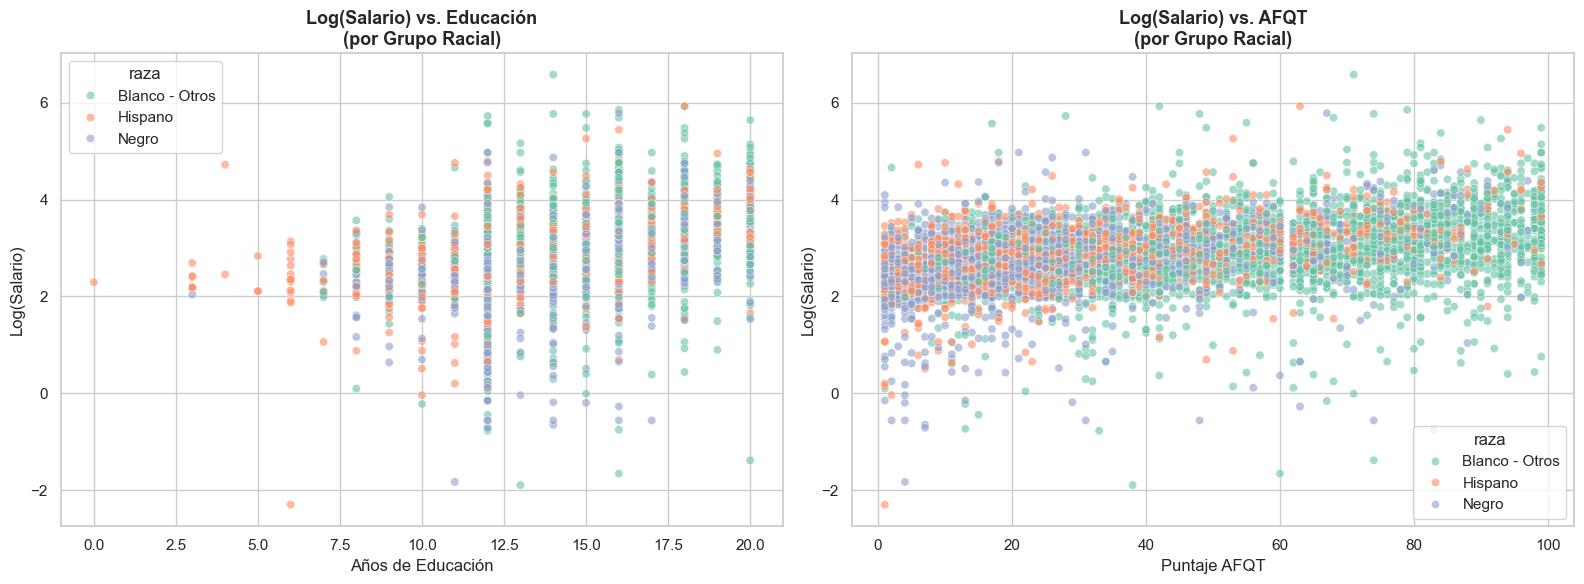

In [48]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_wage, 
    x='educacion', 
    y='ln_salario_hora', 
    hue='raza', 
    palette='Set2', 
    alpha=0.6, 
    ax=axes[0]
)
axes[0].set_title('Log(Salario) vs. Educación\n(por Grupo Racial)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Años de Educación')
axes[0].set_ylabel('Log(Salario)')


sns.scatterplot(
    data=df_wage, 
    x='afqt_score', 
    y='ln_salario_hora', 
    hue='raza', 
    palette='Set2', 
    alpha=0.6, 
    ax=axes[1]
)
axes[1].set_title('Log(Salario) vs. AFQT\n(por Grupo Racial)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Puntaje AFQT')
axes[1].set_ylabel('Log(Salario)')

# Ajustar márgenes y mostrar
plt.tight_layout()
plt.show()